# PandasAI Quickstart Guide

This notebook demonstrates how to get started with PandasAI and how to use it to analyze data through natural language.

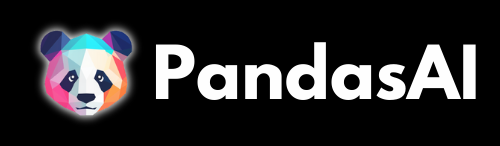


In [1]:
# Importing the required libraries
import pandas as pd
import pandasai as pai
from pandasai_litellm.litellm import LiteLLM
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus
from pathlib import Path
import os
from IPython.display import Image, display

In [3]:
# Load environment variables
load_dotenv()

True

# 1. Getting Familiar with PandasAI
This section will cover the basics of PandasAI, such as loading data and using the .chat() method to talk to it.

## Read Database Directly
For this example, we will load our data directly from our Postgres database using SQLAlquemy 

In [4]:
# Get values from .env
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

In [ ]:
# Create connection to Postgres
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require")

In [6]:
# Connect to Postgres: load .env from project folder and create engine (no stale connection)
PROJECT_DIR = Path(r"c:\Users\TornikePeradze\pandasai-quickstart-guide")
_env_path = PROJECT_DIR / ".env"
load_dotenv(_env_path, override=True)  # override=True so .env wins over system DB_HOST
print("Loading .env from:", _env_path, "| Exists:", _env_path.exists())

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
print("DB_HOST =", repr(DB_HOST), "| DB_USER =", repr(DB_USER))

safe_pass = quote_plus(DB_PASS or "")
base_url = f"postgresql+psycopg2://{DB_USER}:{safe_pass}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
connection_url = base_url if (DB_HOST or "").strip().lower() in ("localhost", "127.0.0.1") else f"{base_url}?sslmode=require"
engine = create_engine(connection_url)

query = "SELECT * FROM customer LIMIT 1000;"
database_df = pd.read_sql(query, engine)
print("Data loaded from Postgres")

database_df.head()

Loading .env from: c:\Users\TornikePeradze\pandasai-quickstart-guide\.env | Exists: True
DB_HOST = 'localhost' | DB_USER = 'postgres'
Data loaded from Postgres


,customer_id,store_id,first_name,last_name,email,address_id,activebool,create_date,last_update,active
0,524,1,Jared,Ely,jared.ely@sakilacustomer.org,530,True,2006-02-14,2013-05-26 14:49:45.738,1
1,1,1,Mary,Smith,mary.smith@sakilacustomer.org,5,True,2006-02-14,2013-05-26 14:49:45.738,1
2,2,1,Patricia,Johnson,patricia.johnson@sakilacustomer.org,6,True,2006-02-14,2013-05-26 14:49:45.738,1
3,3,1,Linda,Williams,linda.williams@sakilacustomer.org,7,True,2006-02-14,2013-05-26 14:49:45.738,1
4,4,2,Barbara,Jones,barbara.jones@sakilacustomer.org,8,True,2006-02-14,2013-05-26 14:49:45.738,1


## Set up LLM

Use `pandasai_litellm` to select the LLM of your choice and use PandasAI

In [ ]:
# Step 1: Load semantic layer into Python memory

with open(r"C:\Users\TornikePeradze\Desktop\AI_Workflows_Bootcamp\dvd-semantic-layer\compiled_semantic_layer.yaml", "r") as f:
    semantic_context = f.read()

# Confirm it loaded correctly
print("Semantic layer loaded. Characters:", len(semantic_context))

# Step 2: Rebuild LLM (Note: system_message parameter is not supported by LiteLLM)
# The semantic context can be included in queries or configured through PandasAI's config

llm = LiteLLM(
    model="gpt-4o-mini"  # Fixed: gpt-4.1-mini doesn't exist, use gpt-4o-mini or gpt-4o
)

pai.config.set({"llm": llm})
print("LLM configured.")

Semantic layer loaded. Characters: 18107
LLM configured with semantic context.


## Chat with your data
Now we will use the .chat() method to chat with our data

In [29]:
# Convert our normal pandas dataframe to a pandasai dataframe
database_df = pai.DataFrame(database_df)

In [30]:
# Chat with the dataframe
response = database_df.chat("How many active customers are there?")
print(response)


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



BadRequestError: litellm.BadRequestError: OpenAIException - Unrecognized request argument supplied: system_message

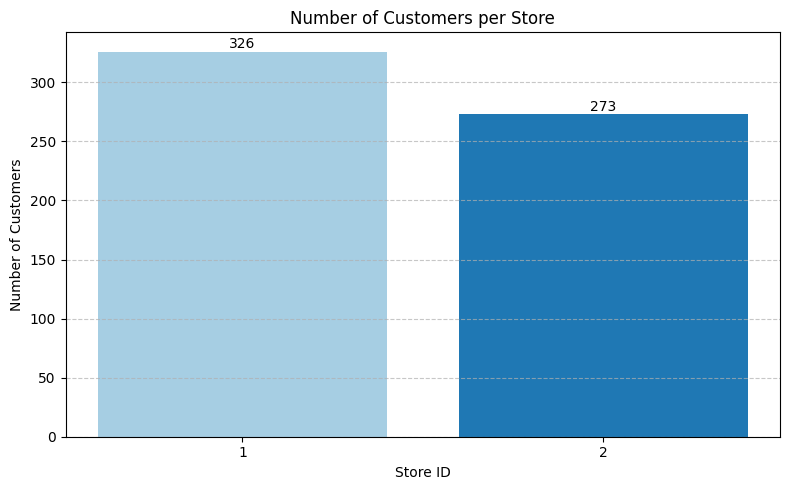

In [15]:
response = database_df.chat("Plot a bar chart of customers per store_id, use a different color per bar, and show the exact count on top of each bar.")

# Extract the path if needed for other purposes
chart_path = response.path if hasattr(response, 'path') else str(response)
# Don't call display() - PandasAI already displayed it

In [16]:
# Chat with the dataframe
response = database_df.chat("Which store has a higher percentage of active customers?")
print(response)

Store 2.0 has the highest percentage of active customers: 100.0%.


## Read Database using PandasAI DB Data Extensions

Now we will learn how to load our data from our Postgres database using the .create() method. This will also create a dataset (locally) which can be reloaded in the future.

In [17]:
# Create a dataset once from the users table which can be reused anytime.
users_dataset = pai.create(

    # Format: "organization/dataset"
    path="public/customer",
    
    # Description of the dataset
    description="DVD rental store customers with store assignment and active status",

    # Source of our data (in this case a PostgreSQL table called users)
    source={
        "type": "postgres",
        "connection": {
            "host": DB_HOST,
            "port": 5432,
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },
        "table": "customer"
    }
)

Dataset saved successfully to path: public\customer


In [18]:
# Chat with the dataframe
response = users_dataset.chat("How many active vs inactive customers are there per store?")
print(response)

   store_id  active  customer_count
0         1       1             318
1         1       0               8
2         2       1             266
3         2       0               7


## Load Dataset
After creation you load your datasets anytime with the following code

In [19]:
# Load the dataset we created in the previous step using the .create() method
dataset = pai.load("public/customer")

Dataset loaded successfully.


# 2. Using a Semantic Layer in PandasAI
In this section, we will explore how to use a semantic layer in PandasAI in order to improve the accuracy of the AI agent.

## Adding Column Information

In [ ]:
# Create a dataset once from the subscriptions table which can be reused anytime.
subscriptions_dataset = pai.create(

    # Format: "organization/dataset"
    path="public/subscriptions",
    
    # Description of the dataset
    description="Tracks user subscriptions to different plans",

    # Source of our data (in this case a PostgreSQL table called subscriptions)
    source={
        "type": "postgres",
        "connection": {
            "host": DB_HOST,
            "port": 5432,
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },
        "table": "subscriptions",

        # Define the structure and metadata of your dataset's columns.
        # If not provided, all columns from the input dataframe will be included.
        "columns": [
            {
                "name": "subscription_id",
                "type": "integer",
                "description": "Unique identifier for the subscription"
            },
            {
                "name": "user_id",
                "type": "integer",
                "description": "Foreign key linking to the users table"
            },
            {
                "name": "plan",
                "type": "string",
                "description": "The subscription plan (e.g., free, monthly, annual)"
            },
            {
                "name": "start_date",
                "type": "datetime",
                "description": "Date when the subscription started"
            },
            {
                "name": "end_date",
                "type": "datetime",
                "description": "Date when the subscription ended (if applicable)"
            },
            {
                "name": "status",
                "type": "string",
                "description": "Current status of the subscription (e.g., active, canceled, expired)"
            }
        ]
    }
)

## Enhancing Your Semantic Layer

The semantic layer you just created can be further enhanced with additional features to improve AI accuracy and data understanding:

### What else can you add?

- **Column Expressions**: Define calculated/derived columns using formulas (e.g., `total_revenue = transaction_amount * (1 + tax_rate)`)
- **Column Aliases**: Create alternative names for columns to improve natural language understanding
- **Transformations**: Apply data transformations like anonymization or timezone conversion
- **Group By**: Specify which columns can be used for grouping operations

### How to add them?

These features must be added by **editing the schema.yaml file directly** in `datasets/public/subscriptions/schema.yaml`. 

For example, to add an alias and expression:
```yaml
columns:
  - name: plan
    type: string
    description: The subscription plan
    alias: subscription_plan  # Alternative name
  - name: subscription_length_days
    type: integer
    description: Length of subscription in days
    expression: "EXTRACT(DAY FROM (COALESCE(end_date, CURRENT_DATE) - start_date))"  # Calculated column
```

For detailed documentation on building a comprehensive semantic layer, including examples of expressions, aliases, transformations, and group_by configurations, visit:

📚 **[PandasAI Semantic Layer Documentation](https://docs.pandas-ai.com/v3/semantic-layer/new)**

This will help you create a more powerful and accurate AI agent that better understands your data and business logic.